# CEE6501 — Coding Assignment, Week 10

**Assigned:** 03/20/2026 (Week 10)  
**Due:** 03/30/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320768>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Name this notebook as: `LastName_A#_code.ipynb`
- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - Permissions on the file are properly set for others to access
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---
---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [ ]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Running in Google Colab
Python version: 3.12.13
numpy: 2.4.0 (required: 2.4.0)
scipy: 1.16.3 (required: 1.16.3)
matplotlib: 3.10.8 (required: 3.10.8)
pandas: 2.3.3 (required: 2.3.3)
plotly: 6.5.2 (required: 6.5.2)

All required package versions already installed.


## Imports & Version Check

Run this cell once before starting the assignment to import packages.

In [ ]:
import numpy as np
import scipy
import matplotlib
import pandas as pd
import plotly

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pd.__version__)
print("plotly:", plotly.__version__)

import matplotlib.pyplot as plt
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


---
---

## Assignment Instructions

In this assignment, you will build on your frame-analysis code from `A8_code.ipynb`:

1. Extend your solver to handle **prescribed support displacements** (support settlements).
2. Extend your solver to handle **temperature effects**
3. Extend your solver to handle **fabrication error effects**

Confirm your code is correct by validating using your hand calculated solutions for the all the questions in `A10_written.md`
- Question 1 — Support Displacements
- Question 2 — Temperature Effects
- Question 3 — Fabrication / Fit-up Errors

### Response (For each question)

Address the following points:

- **Verification:**  
  Confirm whether your computed results match your hand calculations.  
  Identify which quantities you compared (for example: key displacements, reactions, or member end forces).

- **Key results:**  
  Summarize the most important outcomes from your analysis, including representative:
  - **nodal displacements**
  - **support reactions**
  - **member end forces**

- **Reasonableness check:**  
  Briefly explain why the results make sense from a **structural mechanics perspective** (for example: expected deformation direction, magnitude of reactions, or moment distribution).

### Notes
- Use consistent DOF ordering (as in lecture). For a 2D frame node, a common ordering is:
  - $[u_x,\; u_y,\; \theta_z]$ per node
- Clearly document your conventions at the top of your code.
- Use **plots** to help validate and interpret results.

---

In [ ]:

# Extend your solver from A8_code.ipynb to add in support displacements, temperature effects, and fabrication errors
#
# Add your code below (use as many cells as you need). Make sure to include comments and explanations of your code.
#
# Keep your code modular and organized


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)


In [ ]:
def assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qf_list,
    map_list,
):
    """
    Assemble global stiffness matrix and global fixed-end force vector.

    Automatically handles 6-DOF (frame) and 4-DOF (truss/beam) elements.
    Parameters
    ----------
    ndof : int
        Total number of global degrees of freedom.

    k_list : list of ndarray
        List of local element stiffness matrices.
        Each matrix may be 6x6 (frame) or 4x4 (truss/beam).

    T_list : list of ndarray
        List of element transformation matrices corresponding
        to each k_local. Must be compatible in size.

    Qf_list : list of ndarray
        List of local fixed-end force vectors for each element.
        Size must match the element DOF count.

    map_list : list of array-like
        List of element DOF maps (1-based indexing).
        Each map defines where the element DOFs connect
        into the global DOF numbering.

    Returns
    -------
    K_global : ndarray (ndof x ndof)
        Assembled global stiffness matrix.

    F_fef_global : ndarray (ndof,)
        Assembled global fixed-end force vector.

    Notes
    -----
    - DOF maps are assumed to use 1-based indexing.
    - Internally converted to 0-based indexing for Python.
    - Assembly is dense; for large systems a sparse format
      should be used instead.
    """

    K_global = np.zeros((ndof, ndof), dtype=float)
    F_fef_global = np.zeros(ndof, dtype=float)

    nelem = len(k_list)

    for i in range(nelem):

        k_local = k_list[i]
        T = T_list[i]
        Qf_local = Qf_list[i]
        dof_map = map_list[i]  # 1-based indexing

        # Determine element DOF count automatically
        edof = k_local.shape[0]

        # Transform to global
        K = T.T @ k_local @ T
        F_fef = T.T @ Qf_local

        # Scatter-add
        for a in range(edof):
            A = dof_map[a] - 1  # convert to 0-based

            F_fef_global[A] += F_fef[a]

            for b in range(edof):
                B = dof_map[b] - 1
                K_global[A, B] += K[a, b]

    return K_global, F_fef_global


def partition_system(K, f, u, f_fef, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(int(d) - 1 for d in dof_restrained_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    # Partition displaced vector
    u_r = u[restrained_dofs]

    # Partition fixed-end forces
    f_fef_f = f_fef[free_dofs]
    f_fef_r = f_fef[restrained_dofs]

    return (
        K_ff,
        K_fr,
        K_rf,
        K_rr,
        f_f,
        f_r,
        u_r,
        f_fef_f,
        f_fef_r,
        free_dofs,
        restrained_dofs,
    )


def assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    if u_r is None:
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global


def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global


In [ ]:
def print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    dof_fictitious_1based=None,  # ← optional kwarg
    disp_in_mm=False,
):

    ndof = len(u_global)
    rows = []

    # Ensure arrays
    dof_restrained_1based = np.atleast_1d(dof_restrained_1based)

    if dof_fictitious_1based is None:
        dof_fictitious_1based = np.array([], dtype=int)
    else:
        dof_fictitious_1based = np.atleast_1d(dof_fictitious_1based)

    restrained_set = {int(d) for d in dof_restrained_1based}
    fictitious_set = {int(d) for d in dof_fictitious_1based}

    for i in range(ndof):
        dof_1based = i + 1
        mod = i % 3

        if mod == 0:
            dof_type = "u_x"
            disp = u_global[i] * (1000 if disp_in_mm else 1)
        elif mod == 1:
            dof_type = "u_y"
            disp = u_global[i] * (1000 if disp_in_mm else 1)
        else:
            dof_type = "theta"
            disp = u_global[i]

        if dof_1based in fictitious_set:
            status = "Fictitious"
        elif dof_1based in restrained_set:
            status = "Fixed"
        else:
            status = "Free"

        rows.append([dof_1based, dof_type, status, disp, f_global_complete[i]])

    disp_unit = "mm" if disp_in_mm else "m"

    df = pd.DataFrame(
        rows,
        columns=[
            "DOF",
            "Type",
            "Status",
            f"Disp ({disp_unit} / rad)",
            "Load (kN / kN·m)",
        ],
    )

    print(df.to_string(index=False, float_format="%.3f"))


def print_element(
    e, u_global, m_1based, T, k, Qf, disp_in_mm=False, dec=3, rad_dec=4
):

    idx = m_1based - 1
    u = u_global[idx]
    v = T @ u
    q = k @ v + Qf

    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"
    u_out = u.copy()
    v_out = v.copy()
    for j in [0, 1, 3, 4]:
        u_out[j] *= scale
        v_out[j] *= scale

    def fmt_disp(vec):
        parts = []
        for j, val in enumerate(vec):
            if j % 3 == 2:  # rotation (rad)
                parts.append(f"{val:.{rad_dec}f}")
            else:  # translation
                parts.append(f"{val:.{dec}f}")
        return "[" + ", ".join(parts) + "]"

    def fmt_force(vec):
        return "[" + ", ".join(f"{val:.{dec}f}" for val in vec) + "]"

    print(f"\nE{e}")
    print(f"u [{unit},rad]: {fmt_disp(u_out)}")
    print(f"v [{unit},rad]: {fmt_disp(v_out)}")
    print(f"q [kN,kN·m]: {fmt_force(q)}")


def print_element_truss(
    e,
    u_global,
    m_1based,
    T,
    k_local,
    Qf_local=None,
    disp_in_mm=False,
    dec=3,
):
    """
    Print element-level results for a 2D truss element.

    Parameters
    ----------
    e : int
        Element number for printing.
    u_global : (ndof,) array
        Global displacement vector.
    m_1based : (4,) array-like
        Global DOF map for this element (1-based indexing).
    T : (4,4) array
        Transformation matrix (global -> local).
    k_local : (4,4) array
        Local truss stiffness matrix (typically axial-only with 1/-1 pattern).
    Qf_local : (4,) array or None
        Local fixed-end / initial-force vector. If None, assumed zero.
        (Usually zero for trusses unless you model prestrain/temperature/etc.)
    disp_in_mm : bool
        If True, print translations in mm.
    dec : int
        Decimal places for printing.

    Prints
    ------
    - Element global displacement subvector u_e (translations)
    - Element local displacement vector u'_e
    - Element local end force vector q'_e
    - Axial force N (tension positive), computed as N = Fx_j' = -Fx_i'
    """

    idx = np.asarray(m_1based, dtype=int) - 1
    u_e = u_global[idx]  # [uix, uiy, ujx, ujy]

    if Qf_local is None:
        Qf_local = np.zeros(4, dtype=float)

    u_loc = T @ u_e
    q_loc = k_local @ u_loc + Qf_local  # [Fx_i', Fy_i', Fx_j', Fy_j']

    # scale translations for printing
    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"
    u_out = u_e * scale
    uloc_out = u_loc * scale

    def fmt(vec):
        return "[" + ", ".join(f"{v:.{dec}f}" for v in vec) + "]"

    # axial force (tension +): for a pure truss, Fy' should be ~0
    # N_i = q_loc[0]  # Fx at i in local axis
    N_j = q_loc[2]  # Fx at j in local axis
    N = N_j  # report axial as end force at j (should equal -N_i)

    print(f"\nE{e} (Truss)")
    print(f"u_global [{unit}]: {fmt(u_out)}")
    print(f"u_local  [{unit}]: {fmt(uloc_out)}")
    print(f"q_local  [kN]: {fmt(q_loc)}")
    print(f"N (tension +) = {N:.{dec}f} kN\n")


def print_matrix_scaled(K, scale=1000, decimals=1, col_width=3):
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:02d} | {row_str}")


def plot_truss_deformation(nodes, elements, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    plt.figure()

    for e_id, (i, j, *_) in elements.items():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        ui = u_global[2 * (i - 1) : 2 * (i - 1) + 2]
        uj = u_global[2 * (j - 1) : 2 * (j - 1) + 2]

        # original
        plt.plot([xi, xj], [yi, yj], "k-", lw=2)

        # deformed
        plt.plot(
            [xi + scale * ui[0], xj + scale * uj[0]],
            [yi + scale * ui[1], yj + scale * uj[1]],
            "r-",
            lw=2,
        )

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()


In [ ]:
np.set_printoptions(precision=3, suppress=True)
def elem_length_cs(nodes, i, j):

    xi, yi = nodes[i]
    xj, yj = nodes[j]
    dx = xj - xi
    dy = yj - yi
    L = float(np.hypot(dx, dy))
    c = dx / L
    s = dy / L
    return L, c, s


def frame_elem_dof_map(i, j):

    return np.array(
        [
            3*(i-1) + 1, 3*(i-1) + 2, 3*(i-1) + 3,
            3*(j-1) + 1, 3*(j-1) + 2, 3*(j-1) + 3,
        ],
        dtype=int, )


def global_vector_to_local_components(px, py, c, s):
    p_local_x =  px*c + py*s
    p_local_y = -px*s + py*c
    return p_local_x, p_local_y

In [ ]:

def k_frame_local(E, A, I, L):
    EA_L = E * A / L
    EI = E * I

    k = np.array(
        [
            [ EA_L,        0.0,          0.0, -EA_L,        0.0,          0.0],
            [ 0.0,   12*EI/L**3,   6*EI/L**2,  0.0,  -12*EI/L**3,   6*EI/L**2],
            [ 0.0,    6*EI/L**2,    4*EI/L,    0.0,   -6*EI/L**2,    2*EI/L],
            [-EA_L,       0.0,          0.0,  EA_L,        0.0,          0.0],
            [ 0.0,  -12*EI/L**3,  -6*EI/L**2,  0.0,   12*EI/L**3,  -6*EI/L**2],
            [ 0.0,    6*EI/L**2,    2*EI/L,    0.0,   -6*EI/L**2,    4*EI/L],
        ],
        dtype=float,
    )
    return k


def T_frame_2d(c, s):

    T = np.array(
        [
            [ c,  s, 0.0, 0.0, 0.0, 0.0],
            [-s,  c, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0,  c,  s, 0.0],
            [0.0, 0.0, 0.0, -s,  c, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
        ],
        dtype=float,
    )
    return T


def fef_uniform_perpendicular(wy, L):

    return np.array(
        [0.0, wy*L/2.0, wy*L**2/12.0, 0.0, wy*L/2.0, -wy*L**2/12.0],
        dtype=float,
    )


def fef_point_midspan_perpendicular(P, L):
    return np.array(
        [0.0, P/2.0, P*L/8.0, 0.0, P/2.0, -P*L/8.0],
        dtype=float,
    )


def build_frame_lists(nodes, elements, ndof_per_node=3):

    k_list, T_list, Qf_list, m_list = [], [], [], []

    for eid in sorted(elements.keys()):
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A, I = e["E"], e["A"], e["I"]

        L, c, s = elem_length_cs(nodes, i, j)
        k_local = k_frame_local(E, A, I, L)
        T = T_frame_2d(c, s)

        Qf_local = np.zeros(6, dtype=float)


        loads = e.get("loads", [])
        for ld in loads:
            ltype = ld["type"]

            if ltype == "udl_global":
                px, py = ld["px"], ld["py"]
                _, wy = global_vector_to_local_components(px, py, c, s)
                Qf_local += fef_uniform_perpendicular(wy, L)

            elif ltype == "point_mid_global":
                # global point load at midspan (px, py)
                px, py = ld["px"], ld["py"]
                _, Py_local = global_vector_to_local_components(px, py, c, s)
                Qf_local += fef_point_midspan_perpendicular(Py_local, L)


        k_list.append(k_local)
        T_list.append(T)
        Qf_list.append(Qf_local)
        m_list.append(frame_elem_dof_map(i, j))

    ndof = ndof_per_node * len(nodes)
    return k_list, T_list, Qf_list, m_list, ndof

In [ ]:

def solve_frame_dsm(nodes, elements, restrained_dofs, F_global=None):

    k_list, T_list, Qf_list, m_list, ndof = build_frame_lists(nodes, elements)

    K_global, Ff_global = assemble_global_stiffness_and_fef(
        ndof, k_list, T_list, Qf_list, m_list
    )

    if F_global is None:
        F_global = np.zeros(ndof, dtype=float)
    else:
        F_global = np.asarray(F_global, dtype=float).reshape(-1)

    u_prescribed = np.zeros(ndof, dtype=float)

    (
        K_ff,
        K_fr,
        K_rf,
        K_rr,
        f_f,
        f_r,
        u_r,
        f_fef_f,
        f_fef_r,
        free_dofs,
        restrained_dofs_0based,
    ) = partition_system(K_global, F_global, u_prescribed, Ff_global, restrained_dofs)

    rhs = f_f - f_fef_f
    u_f = np.linalg.solve(K_ff, rhs)

    u_global = assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs_0based)

    F_r = K_rf @ u_f + f_fef_r
    R_global = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs_0based)

    return u_global, R_global, K_global, Ff_global, k_list, T_list, Qf_list, m_list


def recover_element_results(nodes, elements, u_global, k_list, T_list, Qf_list, m_list):
    u_global = np.asarray(u_global, dtype=float).reshape(-1)

    results = {}
    eids_sorted = sorted(elements.keys())

    for idx, eid in enumerate(eids_sorted):
        e = elements[eid]
        i, j = e["i"], e["j"]

        L, c, s = elem_length_cs(nodes, i, j)

        k_local = k_list[idx]
        T = T_list[idx]
        Qf_local = Qf_list[idx]
        m = m_list[idx]

        u_elem_global = u_global[m - 1]
        u_local = T @ u_elem_global
        q_local = k_local @ u_local + Qf_local

        results[eid] = {
            "u_local": u_local,
            "q_local": q_local,
            "L": L,
            "c": c,
            "s": s,
            "i": i,
            "j": j,
        }

    return results

In [ ]:
def plot_deformed_frame_2d(nodes, elements, U, scale=1.0, npts=50):
    U = np.asarray(U, dtype=float).reshape(-1)

    fig, ax = plt.subplots(figsize=(10, 6))
    first_und = True
    first_def = True


    for nid, (x, y) in nodes.items():
        ax.plot(x, y, "ko", ms=4)
        ax.text(x, y, f" {nid}", fontsize=9, va="bottom")

    for e_id, e in elements.items():

        i, j =e[0], e[1]
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        dx = xj - xi
        dy = yj - yi
        L = float(np.hypot(dx, dy))
        c = dx / L
        s = dy / L
        print("element:", e_id, "i j", i, j, "L", L)
        T = np.array([
            [ c,  s, 0,  0,  0, 0],
            [-s,  c, 0,  0,  0, 0],
            [ 0,  0, 1,  0,  0, 0],
            [ 0,  0, 0,  c,  s, 0],
            [ 0,  0, 0, -s,  c, 0],
            [ 0,  0, 0,  0,  0, 1],
        ], dtype=float)


        ve = np.array([
            U[3*(i-1) + 0], U[3*(i-1) + 1], U[3*(i-1) + 2],
            U[3*(j-1) + 0], U[3*(j-1) + 1], U[3*(j-1) + 2],
        ], dtype=float)


        ue = T @ ve
        ux_i, uy_i, th_i, ux_j, uy_j, th_j = ue

        x = np.linspace(0.0, L, npts)
        r = x / L


        Nax1 = 1-r
        Nax2 = r
        uax = Nax1*ux_i +Nax2*ux_j

        N1 = 1 - 3*r**2 + 2*r**3
        N2 = L*(r - 2*r**2 + r**3)
        N3 = 3*r**2 -2*r**3
        N4 = L*(-r**2 + r**3)
        vtr = N1*uy_i + N2*th_i + N3*uy_j + N4*th_j


        xloc0 = x
        yloc0 =np.zeros_like(x)

        xlocd = x + scale*uax
        ylocd = scale*vtr


        X0 = xi + c*xloc0- s*yloc0
        Y0 = yi + s*xloc0 + c*yloc0

        Xd = xi +c*xlocd - s*ylocd
        Yd = yi + s*xlocd + c*ylocd

        ax.plot(X0, Y0, color="0.7", lw=2, label="Undeformed" if first_und else None)
        ax.plot(Xd, Yd, lw=2.5, label="Deformed" if first_def else None)

        mid = npts // 2
        ax.text(X0[mid], Y0[mid], f"e{e_id}", fontsize=8, color="0.35")

        first_und = False
        first_def = False

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.set_title(f"Frame Deformed Shape (scale={scale:g})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()

In [ ]:

def make_u_prescribed(ndof, prescribed_dict_1based=None):
    u0 = np.zeros(ndof, dtype=float)
    if prescribed_dict_1based is None:
        return u0

    for dof1, val in prescribed_dict_1based.items():
        dof1 = int(dof1)
        u0[dof1 - 1] = float(val)

    return u0


def make_F_global(ndof, nodal_loads_dict_1based=None):
    F = np.zeros(ndof, dtype=float)
    if nodal_loads_dict_1based is None:
        return F

    for dof1, val in nodal_loads_dict_1based.items():
        dof1 = int(dof1)
        F[dof1 - 1] = float(val)

    return F


def solve_frame_with_prescribed_ur(nodes, elements, restrained_dofs, u_prescribed_full, F_global=None):

    # Build element lists and assemble global K and global fixed-end vector (member loads)
    k_list, T_list, Qf_list, m_list, ndof = build_frame_lists(nodes, elements)

    K_global, Ff_global = assemble_global_stiffness_and_fef(
        ndof, k_list, T_list, Qf_list, m_list
    )

    # External nodal loads
    if F_global is None:
        F_global = np.zeros(ndof, dtype=float)
    else:
        F_global = np.asarray(F_global, dtype=float).reshape(-1)

    # Prescribed displacement vector (full length)
    u_prescribed_full = np.asarray(u_prescribed_full, dtype=float).reshape(-1)

    # Partition system using helper
    K_ff, K_fr, K_rf, K_rr, f_f, f_r, u_r, f_fef_f, f_fef_r, free_dofs0, restrained_dofs0 = partition_system(
        K_global, F_global, u_prescribed_full, Ff_global, restrained_dofs
    )

    # Solve with settlement term
    rhs = f_f - (K_fr @ u_r) - f_fef_f
    u_f = np.linalg.solve(K_ff, rhs)

    # Assemble full u
    u_global = assemble_global_displacements(u_f, u_r, free_dofs0, restrained_dofs0)

    # Reactions at restrained DOFs
    R_r = (K_rf @ u_f) + (K_rr @ u_r) + f_fef_r - f_r

    # Full global force vector
    R_global = assemble_global_forces(f_f, R_r, free_dofs0, restrained_dofs0)

    return u_global, R_global, K_global, Ff_global, k_list, T_list, Qf_list, m_list, restrained_dofs# -------------------------

def qtemp_local_uniform(E, A, alpha, Tu):
    EA = E * A
    N = EA * alpha * Tu
    return np.array([N, 0.0, 0.0, -N, 0.0, 0.0], dtype=float)


def qtemp_local_gradient(E, A, I, alpha, Tb, Tt, d):

    EA = E * A
    EI = E * I
    Tavg = 0.5 * (Tb + Tt)
    qxb = EA * alpha * Tavg
    qxe = -qxb
    qmb = EI * alpha * (Tb - Tt) / d
    qme = -qmb
    return np.array([qxb, 0.0, qmb, qxe, 0.0, qme], dtype=float)


def qfab_local_length_error(E, A, L, ea):

    EA = E * A
    N = (ea * EA / L)
    return np.array([N, 0.0, 0.0, -N, 0.0, 0.0], dtype=float)


def assemble_element_local_to_global_vector(q_local, T, dof_map_1based, ndof_total):

    q_local = np.asarray(q_local, dtype=float).reshape(6)
    T = np.asarray(T, dtype=float).reshape(6, 6)

    q_global_elem = T.T @ q_local

    Fg = np.zeros(ndof_total, dtype=float)
    for k, dof1 in enumerate(dof_map_1based):
        Fg[dof1 - 1] += q_global_elem[k]
    return Fg


def build_Ff_extra_from_temperature(nodes, elements, alpha, d_depth, temp_spec_by_eid):

    ndof = 3 * len(nodes)
    Ff_temp = np.zeros(ndof, dtype=float)

    for eid, spec in temp_spec_by_eid.items():
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A, I = e["E"], e["A"], e["I"]

        L, c, s = elem_length_cs(nodes, i, j)
        T = T_frame_2d(c, s)
        dof_map = frame_elem_dof_map(i, j)

        q_local_total = np.zeros(6, dtype=float)

        stype = spec["type"].lower().strip()
        if stype == "uniform":
            q_local_total += qtemp_local_uniform(E, A, alpha, spec["Tu"])
        elif stype == "gradient":
            q_local_total += qtemp_local_gradient(E, A, I, alpha, spec["Tb"], spec["Tt"], d_depth)
        elif stype == "both":
            q_local_total += qtemp_local_uniform(E, A, alpha, spec["Tu"])
            q_local_total += qtemp_local_gradient(E, A, I, alpha, spec["Tb"], spec["Tt"], d_depth)

        Ff_temp += assemble_element_local_to_global_vector(q_local_total, T, dof_map, ndof)

    return Ff_temp


def build_Ff_extra_from_fabrication(nodes, elements, fab_error_by_eid):
    ndof = 3 * len(nodes)
    Ff_fab = np.zeros(ndof, dtype=float)

    for eid, ea in fab_error_by_eid.items():
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A = e["E"], e["A"]

        L, c, s = elem_length_cs(nodes, i, j)
        T = T_frame_2d(c, s)
        dof_map = frame_elem_dof_map(i, j)

        q_local = qfab_local_length_error(E, A, L, ea)

        Ff_fab += assemble_element_local_to_global_vector(q_local, T, dof_map, ndof)

    return Ff_fab

In [ ]:

def solve_A10_case(
    nodes,
    elements,
    restrained_dofs,
    F_global=None,
    u_prescribed_full=None,
    Ff_extra_global=None,
):
    # ndof
    ndof = 3 * len(nodes)

    # external nodal loads
    if F_global is None:
        F_global = np.zeros(ndof, dtype=float)
    else:
        F_global = np.asarray(F_global, dtype=float).reshape(-1)

    # prescribed displacements
    if u_prescribed_full is None:
        u_prescribed_full = np.zeros(ndof, dtype=float)
    else:
        u_prescribed_full = np.asarray(u_prescribed_full, dtype=float).reshape(-1)


    # extra fixed-end global vector
    if Ff_extra_global is None:
        Ff_extra_global = np.zeros(ndof, dtype=float)
    else:
        Ff_extra_global = np.asarray(Ff_extra_global, dtype=float).reshape(-1)

    element_cache = {}
    k_list, T_list, Qf_list, m_list = [], [], [], []

    for eid in sorted(elements.keys()):
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A, I = e["E"], e["A"], e["I"]

        L, c, s = elem_length_cs(nodes, i, j)
        T = T_frame_2d(c, s)
        k_loc = k_frame_local(E, A, I, L)

        Qf_mech_local = np.zeros(6, dtype=float)
        for ld in e.get("loads", []):
            if ld["type"] == "udl_global":
                px, py = ld["px"], ld["py"]
                _, wy = global_vector_to_local_components(px, py, c, s)
                q = -wy
                Qf_mech_local += fef_uniform_perpendicular(q, L)

            elif ld["type"] == "point_mid_global":
                px, py = ld["px"], ld["py"]
                _, Py = global_vector_to_local_components(px, py, c, s)
                P = -Py
                Qf_mech_local += fef_point_midspan_perpendicular(P, L)

        element_cache[eid] = {
            "i": i, "j": j,
            "L": L, "c": c, "s": s,
            "T": T,
            "k_local": k_loc,
            "Qf_mech_local": Qf_mech_local,
            "dof_map": frame_elem_dof_map(i, j),
        }

        k_list.append(k_loc)
        T_list.append(T)
        Qf_list.append(Qf_mech_local)
        m_list.append(frame_elem_dof_map(i, j))

    # Assemble global stiffness + mechanical global fixed-end vector
    K_global, Ff_mech_global = assemble_global_stiffness_and_fef(
        ndof, k_list, T_list, Qf_list, m_list
    )

    # Total fixed-end vector
    Ff_total_global = Ff_mech_global + Ff_extra_global


    K_ff, K_fr, K_rf, K_rr, f_f, f_r, u_r, f_fef_f, f_fef_r, free_dofs0, restrained_dofs0 = partition_system(
        K_global, F_global, u_prescribed_full, Ff_total_global, restrained_dofs
    )

    rhs = f_f - (K_fr @ u_r) - f_fef_f

    # Solve free displacements
    u_f = np.linalg.solve(K_ff, rhs)

    # Assemble full u
    u_global = assemble_global_displacements(u_f, u_r, free_dofs0, restrained_dofs0)

    # Reactions at restrained DOFs
    R_r = (K_rf @ u_f) + (K_rr @ u_r) + f_fef_r - f_r

    # Full global force vector
    R_global = assemble_global_forces(f_f, R_r, free_dofs0, restrained_dofs0)

    # Build per-element results for reporting
    element_results = {}

    for eid in sorted(elements.keys()):
        cache = element_cache[eid]
        i, j = cache["i"], cache["j"]
        T = cache["T"]
        k_loc = cache["k_local"]
        Qf_mech_local = cache["Qf_mech_local"]
        dof_map = cache["dof_map"]

        # element global displacement vector
        u_elem_global = np.array([u_global[d-1] for d in dof_map], dtype=float)

        # local end displacements
        u_local = T @ u_elem_global

        # k_local * u_local term
        ku_local = k_loc @ u_local

        Qf_total_local = Qf_mech_local.copy()

        # total local end forces based on mechanical local Qf only
        q_local = ku_local + Qf_total_local

        element_results[eid] = {
            "u_elem_global": u_elem_global,
            "u_local": u_local,
            "ku_local": ku_local,
            "Qf_total_local": Qf_total_local,
            "q_local": q_local,
        }

    partitions = {
        "Kff": K_ff, "Kfr": K_fr, "Krf": K_rf, "Krr": K_rr,
        "free_dofs0": free_dofs0, "restrained_dofs0": restrained_dofs0,
    }

    return {
        "ndof": ndof,
        "free_dofs_1based": [d + 1 for d in free_dofs0],
        "restrained_dofs_1based": restrained_dofs,
        "K_global": K_global,
        "F_global": F_global,
        "Ff_mech_global": Ff_mech_global,
        "Ff_extra_global": Ff_extra_global,
        "Ff_total_global": Ff_total_global,
        "u_global": u_global,
        "R_global": R_global,
        "element_cache": element_cache,
        "element_results": element_results,
        "partitions": partitions,
        "rhs_used": rhs,
        "uf_solved": u_f,
        "ur_used": u_r,
    }# -------------------------

def set_element_extra_local_for_reporting(result_dict, extra_local_by_eid=None):

    if extra_local_by_eid is None:
        extra_local_by_eid = {}

    for eid, cache in result_dict["element_cache"].items():
        qextra = extra_local_by_eid.get(eid, None)
        if qextra is None:
            qextra = np.zeros(6, dtype=float)
        qextra = np.asarray(qextra, dtype=float).reshape(6)
        cache["Qextra_local"] = qextra
        res = result_dict["element_results"][eid]

        k_loc = cache["k_local"]
        Qf_mech_local = cache["Qf_mech_local"]

        u_local = res["u_local"]
        ku_local = k_loc @ u_local

        Qf_total_local = Qf_mech_local + qextra
        q_local = ku_local + Qf_total_local

        res["ku_local"] = ku_local
        res["Qf_total_local"] = Qf_total_local
        res["q_local"] = q_local


def compute_and_print_global_equilibrium(result_dict):

    K = result_dict["K_global"]
    u = result_dict["u_global"]
    Ff_total = result_dict["Ff_total_global"]
    F = result_dict["F_global"]

    free = result_dict["partitions"]["free_dofs0"]
    restrained = result_dict["partitions"]["restrained_dofs0"]

    Ku = K @ u
    R_full = Ku + Ff_total - F

    print("\nGlobal equilibrium check")
    print("Ku = K * u")
    print(Ku)

    print("\nR_full = Ku + Ff_total - F")
    print("Ku + Ff_total - F =")
    print(R_full)

    print("\nResidual at free DOFs (should be near zero)")
    print(R_full[free])

    print("\nReactions at restrained DOFs (from R_full entries)")
    print(R_full[restrained])


def print_solve_summary(result_dict):

    Kff = result_dict["partitions"]["Kff"]
    rhs = result_dict["rhs_used"]
    uf = result_dict["uf_solved"]
    ur = result_dict["ur_used"]

    free_1b = result_dict["free_dofs_1based"]
    r_1b = result_dict["restrained_dofs_1based"]

    print("\nSolve summary")
    print("Free DOFs (1-based):", free_1b)
    print("Restrained DOFs (1-based):", r_1b)

    print("\nKff")
    print(Kff)

    print("\nRHS used in Kff * uf = RHS")
    print(rhs)

    print("\nuf solved (same order as free DOFs)")
    print(uf)

    print("\nur used (same order as restrained DOFs)")
    print(ur)


def print_Ff_breakdown(result_dict):

    Ff_mech = result_dict["Ff_mech_global"]
    Ff_extra = result_dict["Ff_extra_global"]
    Ff_total = result_dict["Ff_total_global"]

    print("\nFixed-end vector breakdown")
    print("Ff_total = Ff_mech + Ff_extra")

    print("\nFf_mech")
    print(Ff_mech)

    print("\nFf_extra")
    print(Ff_extra)

    print("\nFf_total")
    print(Ff_total)


def print_element_local_details(result_dict):

    print("\nElement-by-element local reporting")

    for eid in sorted(result_dict["element_cache"].keys()):
        cache = result_dict["element_cache"][eid]
        res = result_dict["element_results"][eid]

        i = cache["i"]
        j = cache["j"]
        L = cache["L"]
        k_loc = cache["k_local"]
        Qf_mech_local = cache["Qf_mech_local"]
        Qextra_local = cache.get("Qextra_local", np.zeros(6, dtype=float))

        u_elem_global = res["u_elem_global"]
        u_local = res["u_local"]

        ku_local = k_loc @ u_local

        Qf_total_local = Qf_mech_local + Qextra_local
        q_local = ku_local + Qf_total_local

        print(f"\nElement {eid}  nodes ({i},{j})  L = {L:g}")

        print("\nu_elem_global")
        print(u_elem_global)

        print("\nu_local = T * u_elem_global")
        print(u_local)

        print("\nk_local * u_local")
        print(ku_local)

        print("\nQf_total_local = Qf_mech_local + Qextra_local")
        print("Qf_mech_local")
        print(Qf_mech_local)
        print("Qextra_local")
        print(Qextra_local)
        print("Qf_total_local")
        print(Qf_total_local)

        print("\nq_local = (k_local*u_local) + (Qf_total_local)")
        print("k_local*u_local")
        print(ku_local)
        print("Qf_total_local")
        print(Qf_total_local)
        print("q_local")
        print(q_local)


def run_full_report(result_dict, extra_local_by_eid=None):
    set_element_extra_local_for_reporting(result_dict, extra_local_by_eid=extra_local_by_eid)

    print_Ff_breakdown(result_dict)
    print_solve_summary(result_dict)
    compute_and_print_global_equilibrium(result_dict)
    print_element_local_details(result_dict)

In [ ]:
def build_extra_local_by_eid_temperature(nodes, elements, alpha, d_depth, temp_spec_by_eid):

    extra_local = {}
    for eid, spec in temp_spec_by_eid.items():
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A, I = e["E"], e["A"], e["I"]
        L, c, s = elem_length_cs(nodes, i, j)

        stype = spec["type"].lower().strip()
        qloc = np.zeros(6, dtype=float)
        if stype == "uniform":
            qloc += qtemp_local_uniform(E, A, alpha, spec["Tu"])
        elif stype == "gradient":
            qloc += qtemp_local_gradient(E, A, I, alpha, spec["Tb"], spec["Tt"], d_depth)
        elif stype == "both":
            qloc += qtemp_local_uniform(E, A, alpha, spec["Tu"])
            qloc += qtemp_local_gradient(E, A, I, alpha, spec["Tb"], spec["Tt"], d_depth)

        extra_local[eid] = qloc

    return extra_local


def build_extra_local_by_eid_fabrication(nodes, elements, fab_error_by_eid):

    extra_local = {}
    for eid, ea in fab_error_by_eid.items():
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A = e["E"], e["A"]
        L, c, s = elem_length_cs(nodes, i, j)

        extra_local[eid] = qfab_local_length_error(E, A, L, ea)

    return extra_local


In [ ]:
def dof_labels_1based(ndof):
    labels = {}
    nnode = ndof // 3
    for n in range(1, nnode + 1):
        labels[3*n-2] = f"u{n}x"
        labels[3*n-1] = f"u{n}y"
        labels[3*n]   = f"th{n}"
    return labels


def print_A8_style_summary(res, title=""):
    ndof = res["ndof"]
    labels = dof_labels_1based(ndof)

    u = res["u_global"]
    R = res["R_global"]
    free = res["free_dofs_1based"]
    rest = res["restrained_dofs_1based"]

    print("\n" + "="*60)
    if title:
        print(title)
    print("="*60)

    print("\nDisplacements at free DOFs")
    for d in free:
        print(f"DOF {d:2d}  {labels[d]:>4s}  = {u[d-1]: .8f}")

    print("\nPrescribed displacements at restrained DOFs")
    ur = res["ur_used"]
    for k, d in enumerate(rest):
        val = float(ur[k])
        if abs(val) > 0:
            print(f"DOF {d:2d}  {labels[d]:>4s}  = {val: .8f}")

    print("\nReactions at restrained DOFs")
    for d in rest:
        print(f"DOF {d:2d}  {labels[d]:>4s}  = {R[d-1]: .6f}")

    print("\nElement end forces (local) for each element")
    for eid in sorted(res["element_results"].keys()):
        q = res["element_results"][eid]["q_local"]
        # local order [N_i, V_i, M_i, N_j, V_j, M_j]
        print(f"\nElement {eid}")
        print(f"N_i = {q[0]: .6f}, V_i = {q[1]: .6f}, M_i = {q[2]: .6f}")
        print(f"N_j = {q[3]: .6f}, V_j = {q[4]: .6f}, M_j = {q[5]: .6f}")

In [ ]:
def plot_case_deformed(res, scale=60, npts=80, title=""):
    u = res["u_global"]
    # plot_deformed_frame_2d uses nodes/elements from outer scope
    if title:
        print("\n" + title)
    plot_deformed_frame_2d(nodes, {eid:(elements[eid]["i"], elements[eid]["j"]) for eid in elements}, u,
                           scale=scale, npts=npts)

In [ ]:

E = 200e6                  # kN/m^2
A = 4740e-6               # m^2
I = 22.2e6 * 1e-12        # m^4

# Geometry
nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0),
}
alpha = 12e-6
d_depth = 0.300
q_col = 24.0
P_beam = 75.0

elements = {
    1: {
        "i": 1, "j": 2,
        "E": E, "A": A, "I": I,
        "loads": [
            {"type": "udl_global", "px": +q_col, "py": 0.0},
        ],
    },
    2: {
        "i": 2, "j": 3,
        "E": E, "A": A, "I": I,
        "loads": [
            {"type": "point_mid_global", "px": 0.0, "py": -P_beam},
        ],
    },
}


restrained_dofs = [1, 2, 3, 7, 8]

ndof = 3 * len(nodes)
all_dofs = list(range(1, ndof + 1))
free_dofs = [d for d in all_dofs if d not in restrained_dofs]


print("A10 frame setup")
print("Nodes:", nodes)
print("Elements:", {eid: (elements[eid]["i"], elements[eid]["j"]) for eid in elements})
print("Restrained DOFs:", restrained_dofs)
print("Free DOFs:", free_dofs)
print("ndof:", ndof)

A10 frame setup
Nodes: {1: (0.0, 0.0), 2: (0.0, 10.0), 3: (8.0, 10.0)}
Elements: {1: (1, 2), 2: (2, 3)}
Restrained DOFs: [1, 2, 3, 7, 8]
Free DOFs: [4, 5, 6, 9]
ndof: 9



A10 Q1 Results

Fixed-end vector breakdown
Ff_total = Ff_mech + Ff_extra

Ff_mech
[-120.     0.   200.  -120.    37.5 -125.     0.    37.5  -75. ]

Ff_extra
[0. 0. 0. 0. 0. 0. 0. 0. 0.]

Ff_total
[-120.     0.   200.  -120.    37.5 -125.     0.    37.5  -75. ]

Solve summary
Free DOFs (1-based): [4, 5, 6, 9]
Restrained DOFs (1-based): [1, 2, 3, 7, 8]

Kff
[[118553.28       0.       266.4        0.   ]
 [     0.     94904.062    416.25     416.25 ]
 [   266.4      416.25    3996.      1110.   ]
 [     0.       416.25    1110.      2220.   ]]

RHS used in Kff * uf = RHS
[709.836 -38.541 111.957  70.838]

uf solved (same order as free DOFs)
[ 0.006 -0.001  0.022  0.021]

ur used (same order as restrained DOFs)
[ 0.     0.     0.01   0.005 -0.01 ]

Global equilibrium check
Ku = K * u
[  -8.793   56.348   38.718  120.     -37.5    125.    -111.207  -18.848
   75.   ]

R_full = Ku + Ff_total - F
Ku + Ff_total - F =
[-128.793   56.348  238.718    0.       0.       0.    -111.207   18.652
   

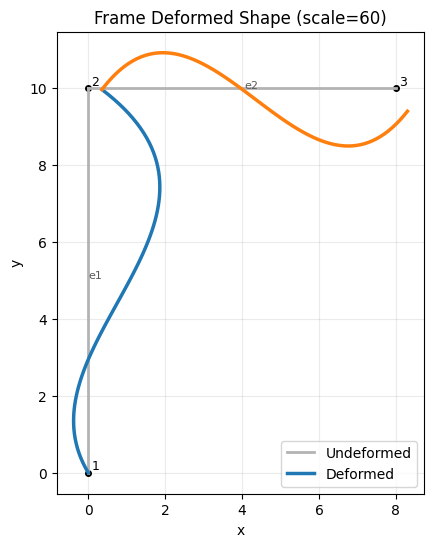

In [ ]:
prescribed_Q1 = {
    3: 0.01,      # theta1
    7: 0.005,     # u3x
    8: -0.010,    # u3y
}
nodal_loads_Q1 = None

ndof = 3 * len(nodes)
u_prescribed_Q1 = make_u_prescribed(ndof, prescribed_Q1)
F_global_Q1 = make_F_global(ndof, nodal_loads_Q1)


Ff_extra_Q1 = np.zeros(ndof, dtype=float)

res_Q1 = solve_A10_case(
    nodes=nodes,
    elements=elements,
    restrained_dofs=restrained_dofs,
    F_global=F_global_Q1,
    u_prescribed_full=u_prescribed_Q1,
    Ff_extra_global=Ff_extra_Q1
)

print("\n====================")
print("A10 Q1 Results")
print("====================")
run_full_report(res_Q1, extra_local_by_eid=None)
print_A8_style_summary(res_Q1, title="A10 Q1 summary")
plot_case_deformed(res_Q1, scale=60, title="A10 Q1 deformed shape")


A10 Q2 Results

Fixed-end vector breakdown
Ff_total = Ff_mech + Ff_extra

Ff_mech
[-120.     0.   200.  -120.    37.5 -125.     0.    37.5  -75. ]

Ff_extra
[   0.     113.76     0.     113.76  -113.76    -1.776 -113.76     0.
    1.776]

Ff_total
[-120.     113.76   200.      -6.24   -76.26  -126.776 -113.76    37.5
  -73.224]

Solve summary
Free DOFs (1-based): [4, 5, 6, 9]
Restrained DOFs (1-based): [1, 2, 3, 7, 8]

Kff
[[118553.28       0.       266.4        0.   ]
 [     0.     94904.062    416.25     416.25 ]
 [   266.4      416.25    3996.      1110.   ]
 [     0.       416.25    1110.      2220.   ]]

RHS used in Kff * uf = RHS
[  6.24   76.26  126.776  73.224]

uf solved (same order as free DOFs)
[-0.     0.001  0.026  0.02 ]

ur used (same order as restrained DOFs)
[0. 0. 0. 0. 0.]

Global equilibrium check
Ku = K * u
[ -6.971 -57.069  23.235   6.24   76.26  126.776   0.731 -19.191  73.224]

R_full = Ku + Ff_total - F
Ku + Ff_total - F =
[-126.971   56.691  223.235    0.    

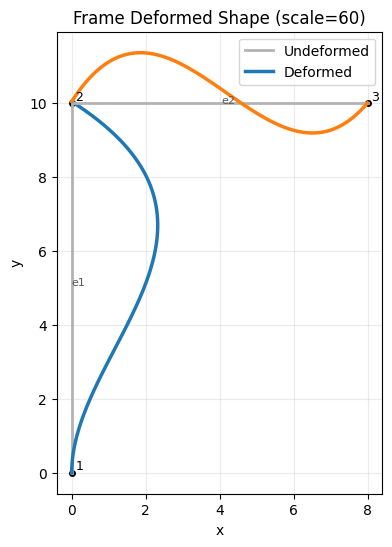

In [ ]:
#Q2
temp_spec_by_eid_Q2 = {
    1: {"type": "uniform", "Tu": 10.0},               # element 1 uniform +10C
    2: {"type": "gradient", "Tb": 5.0, "Tt": 15.0},   # element 2 gradient (top 15, bottom 5)
}


u_prescribed_Q2 = make_u_prescribed(ndof, prescribed_dict_1based=None)
F_global_Q2 = make_F_global(ndof, nodal_loads_dict_1based=None)


Ff_temp_Q2 = build_Ff_extra_from_temperature(nodes, elements, alpha, d_depth, temp_spec_by_eid_Q2)

res_Q2 = solve_A10_case(
    nodes=nodes,
    elements=elements,
    restrained_dofs=restrained_dofs,
    F_global=F_global_Q2,
    u_prescribed_full=u_prescribed_Q2,
    Ff_extra_global=Ff_temp_Q2
)

extra_local_Q2 = build_extra_local_by_eid_temperature(nodes, elements, alpha, d_depth, temp_spec_by_eid_Q2)

print("\n====================")
print("A10 Q2 Results")
print("====================")
run_full_report(res_Q2, extra_local_by_eid=extra_local_Q2)
print_A8_style_summary(res_Q2, title="A10 Q2 summary")
plot_case_deformed(res_Q2, scale=60, title="A10 Q2 deformed shape")


A10 Q3 Results

Fixed-end vector breakdown
Ff_total = Ff_mech + Ff_extra

Ff_mech
[-120.     0.   200.  -120.    37.5 -125.     0.    37.5  -75. ]

Ff_extra
[   0.  -284.4    0.  -355.5  284.4    0.   355.5    0.     0. ]

Ff_total
[-120.  -284.4  200.  -475.5  321.9 -125.   355.5   37.5  -75. ]

Solve summary
Free DOFs (1-based): [4, 5, 6, 9]
Restrained DOFs (1-based): [1, 2, 3, 7, 8]

Kff
[[118553.28       0.       266.4        0.   ]
 [     0.     94904.062    416.25     416.25 ]
 [   266.4      416.25    3996.      1110.   ]
 [     0.       416.25    1110.      2220.   ]]

RHS used in Kff * uf = RHS
[ 475.5 -321.9  125.    75. ]

uf solved (same order as free DOFs)
[ 0.004 -0.004  0.025  0.022]

ur used (same order as restrained DOFs)
[0. 0. 0. 0. 0.]

Global equilibrium check
Ku = K * u
[  -6.961  341.143   23.555  475.5   -321.9    125.    -468.539  -19.243
   75.   ]

R_full = Ku + Ff_total - F
Ku + Ff_total - F =
[-126.961   56.743  223.555    0.       0.      -0.    -113.039 

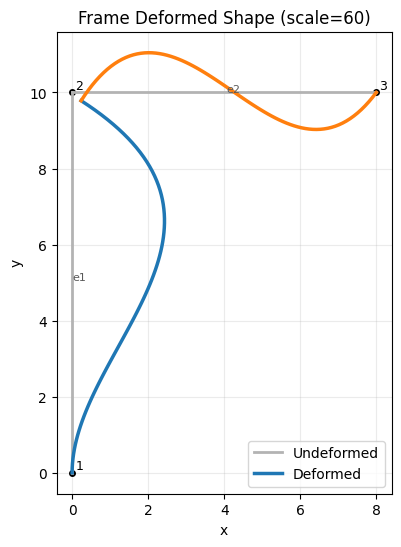

In [ ]:
#Q3
fab_error_by_eid_Q3 = {
    1: -0.003,   # element 1 too short by 3 mm
    2: -0.003,   # element 2 too short by 3 mm
}

# No prescribed displacements for Q3
u_prescribed_Q3 = make_u_prescribed(ndof, prescribed_dict_1based=None)
F_global_Q3 = make_F_global(ndof, nodal_loads_dict_1based=None)

# Build extra global fixed-end vector from fabrication errors
Ff_fab_Q3 = build_Ff_extra_from_fabrication(nodes, elements, fab_error_by_eid_Q3)

res_Q3 = solve_A10_case(
    nodes=nodes,
    elements=elements,
    restrained_dofs=restrained_dofs,
    F_global=F_global_Q3,
    u_prescribed_full=u_prescribed_Q3,
    Ff_extra_global=Ff_fab_Q3
)

extra_local_Q3 = build_extra_local_by_eid_fabrication(nodes, elements, fab_error_by_eid_Q3)

print("\n====================")
print("A10 Q3 Results")
print("====================")
run_full_report(res_Q3, extra_local_by_eid=extra_local_Q3)
print_A8_style_summary(res_Q3, title="A10 Q3 summary")
plot_case_deformed(res_Q3, scale=60, title="A10 Q3 deformed shape")

---

## Response (Question 1)

## Displacements at free DOFs

- DOF 4  u2x = 0.00593846  
- DOF 5  u2y = -0.00059439  
- DOF 6  th2 = 0.02181937  
- DOF 9  th3 = 0.02111055  

## Prescribed displacements at restrained DOFs

- DOF 3  th1 = 0.01000000  
- DOF 7  u3x = 0.00500000  
- DOF 8  u3y = -0.01000000  

## Reactions at restrained DOFs

- DOF 1  u1x = -128.793081  
- DOF 2  u1y = 0.056348349  
- DOF 3  th1 = 238.717605  
- DOF 7  u3x = -111.206919  
- DOF 8  u3y = 18.651651  

## Element end forces, local coordinates

### Element 1

- N_i = 56.348349, V_i = 128.793081, M_i = 238.717605  
- N_j = -56.348349, V_j = 111.206919, M_j = -150.786794  

### Element 2

- N_i = 111.206919, V_i = 56.348349, M_i = 150.786794  
- N_j = -111.206919, V_j = 18.651651, M_j = 0.000000  

## Response (Question 2)

## Displacements at free DOFs

- DOF 4  u2x = -0.00000616  
- DOF 5  u2y = 0.00060199  
- DOF 6  th2 = 0.02616691  
- DOF 9  th3 = 0.01978745  

## Prescribed displacements at restrained DOFs

- None

## Reactions at restrained DOFs

- DOF 1  u1x = -126.970538  
- DOF 2  u1y = 56.691150  
- DOF 3  th1 = 223.234578  
- DOF 7  u3x = -113.029462  
- DOF 8  u3y = 18.308850  

## Element end forces, local coordinates

### Element 1

- N_i = 56.691150, V_i = 126.970538, M_i = 223.234578  
- N_j = -56.691150, V_j = 113.029462, M_j = -153.529202  

### Element 2

- N_i = 113.029462, V_i = 56.691150, M_i = 153.529202  
- N_j = -113.029462, V_j = 18.308850, M_j = 0.000000  

## Response (Question 3)
## Displacements at free DOFs

- DOF 4  u2x = 0.00395391  
- DOF 5  u2y = -0.00359855  
- DOF 6  th2 = 0.02534020  
- DOF 9  th3 = 0.02178841  

## Prescribed displacements at restrained DOFs

- None

## Reactions at restrained DOFs

- DOF 1  u1x = -126.961294  
- DOF 2  u1y = 56.742810  
- DOF 3  th1 = 223.555420  
- DOF 7  u3x = -113.038706  
- DOF 8  u3y = 18.257190  

## Element end forces, local coordinates

### Element 1

- N_i = 56.742810, V_i = 126.961294, M_i = 223.555420  
- N_j = -56.742810, V_j = 113.038706, M_j = -153.942483  

### Element 2

- N_i = 113.038706, V_i = 56.742810, M_i = 153.942483  
- N_j = -113.038706, V_j = 18.257190, M_j = 0.000000  

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics
- What part felt hardest? Describe in speciics
- One bug you encountered and how you fixed it.
- One thing you still don’t understand.
- If you used collaboration or AI tools, briefly describe how.


### YOUR RESPONSE HERE

- What part felt easiest? Describe in speciics

Nothing felt easy in this assignment.
- What part felt hardest? Describe in speciics

The hardest part was deciding how to structure the code. I was not sure if I should modify the previous assignment code directly or keep it unchanged and add to it, and I was also confused about how to organize the workflow so the settlement, temperature, and fabrication cases could be run cleanly and consistently.
- One bug you encountered and how you fixed it.

My reaction forces for Q2 and Q3 were not matching the hand solution at first. I realized the issue was not the solver, but that I was printing element end forces without including the extra local vectors for temperature or fabrication, so the summary was missing those effects. I fixed it by updating the stored element results after adding the extra local vectors so the summary and the detailed element printout were consistent.
- One thing you still don’t understand.

I am still not fully sure if it is possible to combine the effects of all three questions into one single solve and report it as an additional case.
- If you used collaboration or AI tools, briefly describe how.

Such a big code got messy and confusing for me. AI was used to make it more managebale in terms of function and variable names to reduce confusion and understandable for others. Also for finding mistakes and fixing issues.
